In [1]:
# Hurricane Harvey Damage Classification Project

In [2]:
## Part 1: Data Preprocessing and Visualization

In [3]:
# Import all necessary libraries for data loading, preprocessing, visualization, and modeling
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

2025-11-05 22:05:15.280122: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-05 22:05:16.977366: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-05 22:05:16.977534: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-05 22:05:17.187192: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-05 22:05:17.809628: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-05 22:05:17.811842: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [4]:
# Define dataset paths
DATASET_DIR = 'datasets'
DAMAGE_DIR = os.path.join(DATASET_DIR, 'damage')
NO_DAMAGE_DIR = os.path.join(DATASET_DIR, 'no_damage')

# List image files in each class
damage_images = [os.path.join(DAMAGE_DIR, fname) for fname in os.listdir(DAMAGE_DIR) if fname.lower().endswith(('.png', '.jpg', '.jpeg'))]
no_damage_images = [os.path.join(NO_DAMAGE_DIR, fname) for fname in os.listdir(NO_DAMAGE_DIR) if fname.lower().endswith(('.png', '.jpg', '.jpeg'))]

print(f"Number of damaged images: {len(damage_images)}")
print(f"Number of non-damaged images: {len(no_damage_images)}")

# Inspect a few images for shape and format
sample_damage_img = Image.open(damage_images[0])
sample_no_damage_img = Image.open(no_damage_images[0])
print(f"Damaged image size: {sample_damage_img.size}, format: {sample_damage_img.format}")
print(f"Non-damaged image size: {sample_no_damage_img.size}, format: {sample_no_damage_img.format}")

Number of damaged images: 14170
Number of non-damaged images: 7152
Damaged image size: (128, 128), format: JPEG
Non-damaged image size: (128, 128), format: JPEG


In [5]:
# Set image size for resizing
IMG_SIZE = (128, 128)  # Small size for faster training and compatibility with LeNet-5

# Function to load and preprocess images
def load_and_preprocess(image_paths, label):
    images = []
    labels = []
    for path in image_paths:
        img = Image.open(path).convert('RGB')
        img = img.resize(IMG_SIZE)
        img_array = np.array(img) / 255.0  # Normalize pixel values to [0, 1]
        images.append(img_array)
        labels.append(label)
    return images, labels

# Preprocess all images
X_damage, y_damage = load_and_preprocess(damage_images, 1)
X_no_damage, y_no_damage = load_and_preprocess(no_damage_images, 0)

# Combine and create full dataset
X = np.array(X_damage + X_no_damage)
y = np.array(y_damage + y_no_damage)

print(f"Total images: {len(X)}")
print(f"Image shape: {X[0].shape}")

# Train, validation, and test splits
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

Total images: 21322
Image shape: (128, 128, 3)
Training set size: 14925
Validation set size: 3198
Test set size: 3199


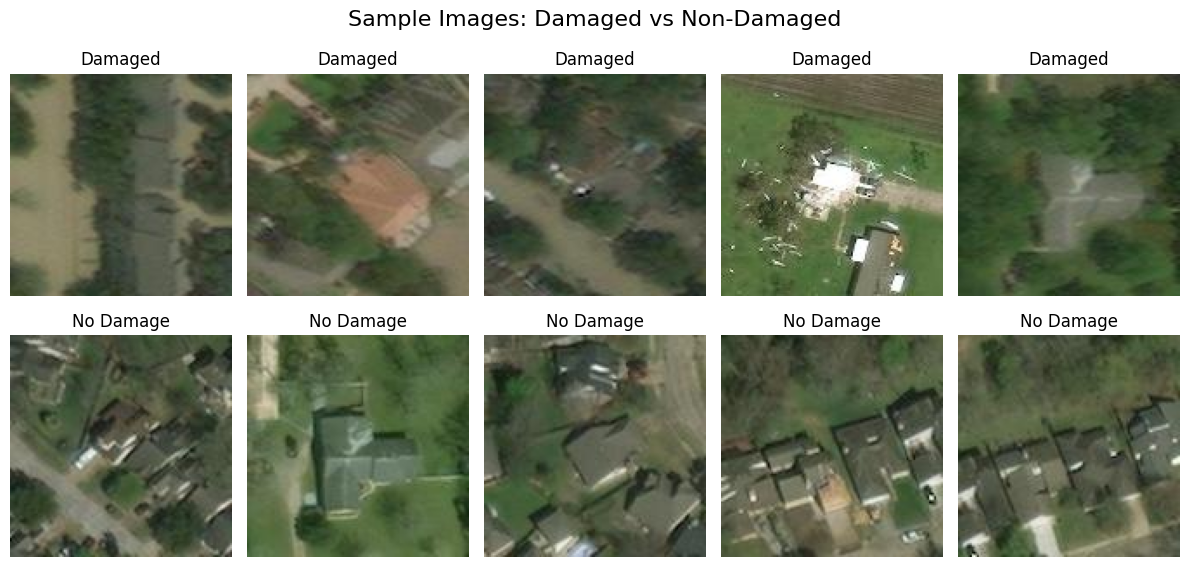

In [6]:
# Sample images from both classes
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample Images: Damaged vs Non-Damaged', fontsize=16)

for i in range(5):
    # Damaged
    img = Image.open(damage_images[i]).resize(IMG_SIZE)
    axes[0, i].imshow(img)
    axes[0, i].set_title('Damaged')
    axes[0, i].axis('off')
    # Non-Damaged
    img = Image.open(no_damage_images[i]).resize(IMG_SIZE)
    axes[1, i].imshow(img)
    axes[1, i].set_title('No Damage')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

In [7]:
## Part 2: Model Design, Training, and Evaluation
#Three different neural network architectures:
#- Dense (fully connected) ANN
#- LeNet-5 CNN
#- Alternate-LeNet-5 CNN (as described in the referenced paper)

#Each model has been:
#- Implemented
#- Trained
#- Evaluated

In [8]:
### Dense (Fully Connected) ANN


In [ ]:
# Flatten images
X_train_flat = X_train.reshape((X_train.shape[0], -1))
X_val_flat = X_val.reshape((X_val.shape[0], -1))
X_test_flat = X_test.reshape((X_test.shape[0], -1))

# Build fully connected CNN
ann_model = keras.Sequential([
    keras.layers.Input(shape=(X_train_flat.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')  # Binary classification
])

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history_ann = ann_model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=3,
    batch_size=4,
    verbose=2
)

# Evaluate on test set
test_loss_ann, test_acc_ann = ann_model.evaluate(X_test_flat, y_test, verbose=0)
print(f"Dense ANN Test Accuracy: {test_acc_ann:.4f}")

In [ ]:
### LeNet-5 CNN Architecture

In [ ]:
# Build the LeNet-5 CNN architecture
lenet5_model = keras.Sequential([
    keras.layers.Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(*IMG_SIZE, 3), padding='same'),
    keras.layers.AveragePooling2D(),
    keras.layers.Conv2D(16, kernel_size=(5, 5), activation='tanh'),
    keras.layers.AveragePooling2D(),
    keras.layers.Flatten(),
    keras.layers.Dense(120, activation='tanh'),
    keras.layers.Dense(84, activation='tanh'),
    keras.layers.Dense(1, activation='sigmoid')
])

lenet5_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history_lenet5 = lenet5_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    verbose=2
)

# Evaluate on test set
test_loss_lenet5, test_acc_lenet5 = lenet5_model.evaluate(X_test, y_test, verbose=0)
print(f"LeNet-5 Test Accuracy: {test_acc_lenet5:.4f}")

In [ ]:
### Alternate-LeNet-5 CNN Architecture

In [ ]:
# Alternate-LeNet-5 architecture based on the referenced paper
alt_lenet5_model = keras.Sequential([
    keras.layers.Conv2D(32, kernel_size=(5, 5), activation='relu', input_shape=(*IMG_SIZE, 3), padding='same'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Conv2D(64, kernel_size=(5, 5), activation='relu', padding='same'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(120, activation='relu'),
    keras.layers.Dense(84, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

alt_lenet5_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history_alt_lenet5 = alt_lenet5_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    verbose=2
)

# Evaluate on test set
test_loss_alt_lenet5, test_acc_alt_lenet5 = alt_lenet5_model.evaluate(X_test, y_test, verbose=0)
print(f"Alternate-LeNet-5 Test Accuracy: {test_acc_alt_lenet5:.4f}")

In [ ]:
### Model Comparison and Selection

In [ ]:
# Compare test accuracies of all models
print("\nModel Test Accuracies:")
print(f"Dense ANN: {test_acc_ann:.4f}")
print(f"LeNet-5 CNN: {test_acc_lenet5:.4f}")
print(f"Alternate-LeNet-5 CNN: {test_acc_alt_lenet5:.4f}")

# Select the best model
accuracies = [test_acc_ann, test_acc_lenet5, test_acc_alt_lenet5]
models = ['Dense ANN', 'LeNet-5 CNN', 'Alternate-LeNet-5 CNN']
best_model_idx = np.argmax(accuracies)
print(f"\nBest model for deployment: {models[best_model_idx]} (Accuracy: {accuracies[best_model_idx]:.4f})")